# Basic Plotting
In this lesson we will learn to use the plot() method of a pandas.DataFrame to create simple exploratory graphs from tabular data

# Learning Objectives
 - intepret data using
   1. info() (structure)
   2. describe() (summary statistics),
   3. nunique() (unique value counts)
   4. unique() (distinct values)
   5. value_counts() (frequency counts)

- Create simple exploratory plots using the plot() method for pandas.DataFrames to visualize trends and distributions
- Understand the concept of performing operations on a pandas.DataFrame in-place
- Apply method chaining to enable concise and readable code

## Bird Data
### Recap

bird data from four wetlands:

- Carpinteria Salt Marsh (CSM)
- Mugu Lagoon (MUL),
- San Dieguito Wetland (SDW)
- Tijuana Estuary (TJE).
Besides year when data was collecteed, other columns = # birds from location during a season: winter, spring, or fall.

Ex: column CSM_fall = # of species recorded in fall at CSM by year.

Years: 2010 to 2023.

In [1]:
# Input libraries
import pandas as pd # panda package
import numpy as np # numpy package
import os # os package

# import data and show first 5 (remember: python starts at 0 not 1!)
fp = os.path.join('data', 'wetlands_seasonal_bird_diversity.csv')
df = pd.read_csv(fp)
df.head()

,year,CSM_winter,CSM_spring,CSM_fall,MUL_winter,MUL_spring,MUL_fall,SDW_winter,SDW_spring,SDW_fall,TJE_winter,TJE_spring,TJE_fall
0,2010,39.0,40.0,50.0,45.0,NaN,61.0,NaN,75.0,85.0,NaN,NaN,81.0
1,2011,48.0,44.0,NaN,58.0,52.0,NaN,78.0,74.0,NaN,67.0,70.0,NaN
2,2012,51.0,43.0,49.0,57.0,58.0,53.0,71.0,72.0,73.0,70.0,63.0,69.0
3,2013,42.0,46.0,38.0,60.0,58.0,62.0,69.0,70.0,70.0,69.0,74.0,64.0
4,2014,38.0,43.0,45.0,49.0,52.0,57.0,61.0,78.0,71.0,60.0,81.0,62.0


## Plot() Method
### Line Plot

<Axes: xlabel='year'>

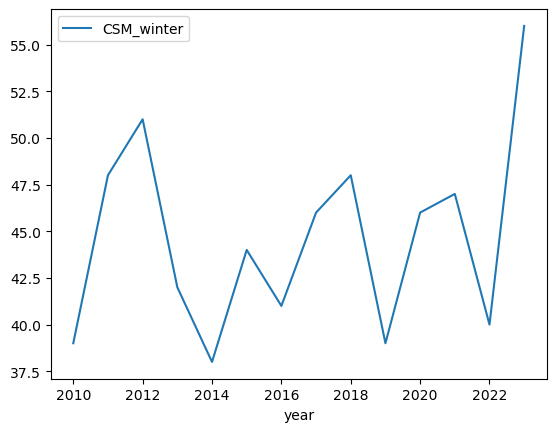

In [2]:
df.plot(x='year', y='CSM_winter')

# Formula: df.plt(x='x_values_column', y='y_values_column')

Basic customization of the plot() method:

- title: title to use for the plot.
- xlabel: name to use for the x-label on x-axis
- ylabel: name to use for the y-label on y-axis
- color: change the color of our plot
- legend: boolean value True or False. True (default) includes the legend, False removes the legend
Ex:

<Axes: title={'center': 'Bird species registered during winter at Carpinteria Salt Marsh'}, xlabel='Year', ylabel='Number of bird species'>

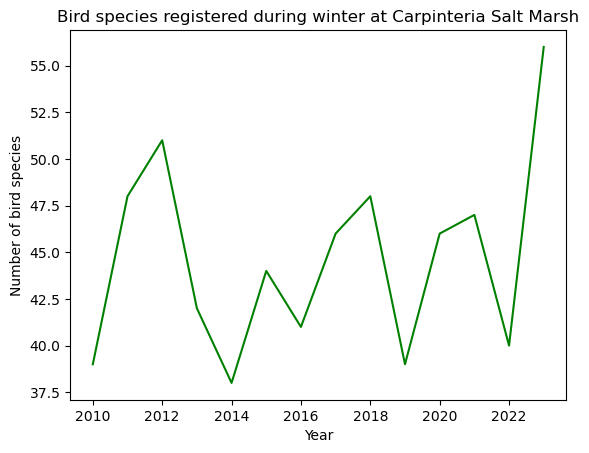

In [3]:
df.plot(x='year', 
        y='CSM_winter',
        title='Bird species registered during winter at Carpinteria Salt Marsh',
        xlabel='Year',
        ylabel='Number of bird species',
        color='green',
        legend=False
        )

### Check-ins
1. Plot a graph of the spring bird surveys at Mugu Lagoon with respect to the years. Include some basic customization.

2. Use the isna() method for pandas.Series and row selection to select the rows in which Mugu Lagoon has NAs during the spring survey.

,year,CSM_winter,CSM_spring,CSM_fall,MUL_winter,MUL_spring,MUL_fall,SDW_winter,SDW_spring,SDW_fall,TJE_winter,TJE_spring,TJE_fall
0,2010,39.0,40.0,50.0,45.0,NaN,61.0,NaN,75.0,85.0,NaN,NaN,81.0
10,2020,46.0,NaN,47.0,56.0,NaN,66.0,57.0,NaN,58.0,54.0,40.0,54.0


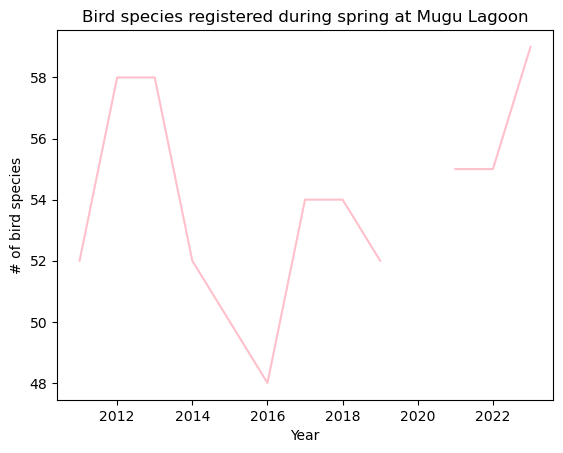

In [10]:
df.plot(x='year', 
        y='MUL_spring',
        title='Bird species registered during spring at Mugu Lagoon',
        xlabel='Year',
        ylabel='# of bird species',
        color='pink',
        legend=False
        )

df[df['MUL_spring'].isna()]

In [5]:
df.isna()

,year,CSM_winter,CSM_spring,CSM_fall,MUL_winter,MUL_spring,MUL_fall,SDW_winter,SDW_spring,SDW_fall,TJE_winter,TJE_spring,TJE_fall
0,False,False,False,False,False,True,False,True,False,False,True,True,False
1,False,False,False,True,False,False,True,False,False,True,False,False,True
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,False,False,False
6,False,False,False,False,False,False,False,False,False,False,False,False,False
7,False,False,False,False,False,False,False,False,False,False,False,False,False
8,False,False,False,False,False,False,False,False,False,False,False,False,False
9,False,False,False,False,False,False,False,False,False,False,False,False,False


### Multiple line plots

plot() method:

y : a list of column names that will be plotted against the x-axis
color: a dictionary {'column_1' : 'color_1', 'column_2':'color_2'} specifying the color of each column’s line plot

<Axes: title={'center': 'Seasonal bird surveys at Tijuana Estuary'}, xlabel='Year', ylabel='Number of bird species'>

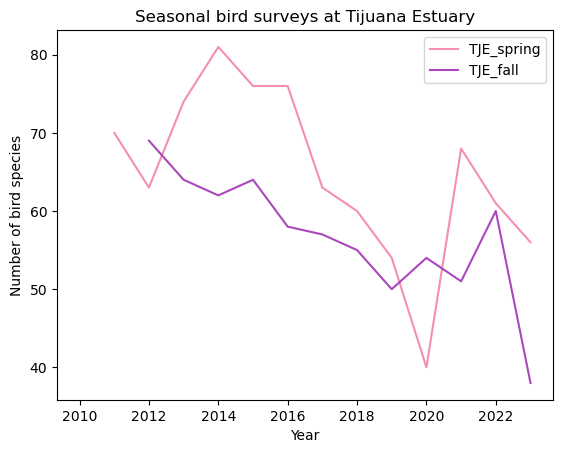

In [6]:
df.plot(x='year', 
        y=['TJE_spring', 'TJE_fall'],
        title = 'Seasonal bird surveys at Tijuana Estuary',
        xlabel='Year',
        ylabel='Number of bird species',        
        color = {'TJE_spring':'#F48FB1',
                 'TJE_fall': '#AB47BC' # notice the HEX code here!
                 }
        )

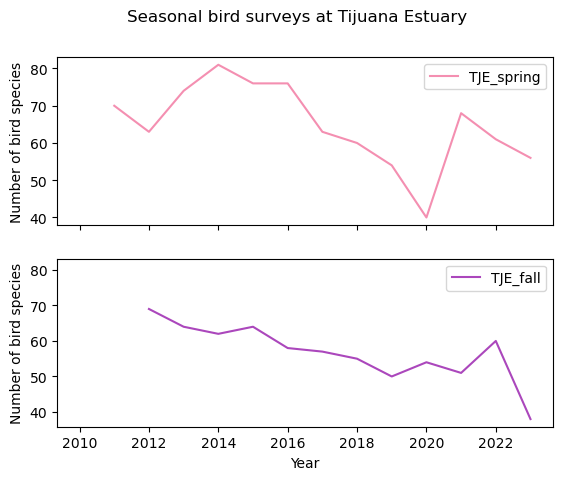

In [7]:
df.plot(x='year', 
        y=['TJE_spring', 'TJE_fall'],
        title = 'Seasonal bird surveys at Tijuana Estuary',
        xlabel='Year',
        ylabel='Number of bird species',        
        color = {'TJE_spring':'#F48FB1',
                 'TJE_fall': '#AB47BC'
                 },
        subplots=True # Changing this **separates plots** by each column!
        ); # semi-colon to remove the text about the plot method

## Updating the index
df = df.set_index(new_index)

where new_index is:

- the name of the column in the data frame df we want to use as new index
- if our new index is not a column in the data frame, an array or pandas.Series of the same length as our data frame (we need one index per row).

Not in one place?
- A function acting in-place means that our original object (in this case a pandas.DataFrame) is modified.
- If the function does not act in-place, a new object (in this case a pandas.DataFrame) is created and the original is not modified.


In [11]:
# Set `column_name` column in df as the new index (reassignment)
# Explicit assignment
# df = df.set_index('column_name')

In [ ]:
# Set `column_name` column in df as the new index (modify df in-place)
# avoid:  df.set_index('column_name', inplace=True)

In [ ]:
# Update index to be the year column
df = df.set_index('year') # by reassigning to the dataframe itself ""=""
df.head()

In [ ]:
# Simple plot of Carpinteria Salt Marsh winter surveys
df.plot(y='CSM_winter') # just y axis since we indexed by year

In [ ]:
df = df.reset_index() # If needed, we can reset the index to be the numbering of the rows:
df.head()


### Check-ins

1. Without running the code, give a step-by-step breakdown of what this code is doing:
df.set_index('year').loc[:,'SDW_winter':'TJE_fall'].plot()

- index by year
- select locations SD Wetlands through Tijuana Fall, which is just those two locations.
- plotting

3. Is this code modifying the data frame df? Why or why not?

   - it is updating the index to be by year.

5. Run the code and examine the graph. Review the data description. Do we have all the necessary information to make sure it makes sense to directly compare the surveys at these different sites?

df.set_index('year').loc[:,'SDW_winter':'TJE_fall'].plot()

<Axes: xlabel='year'>

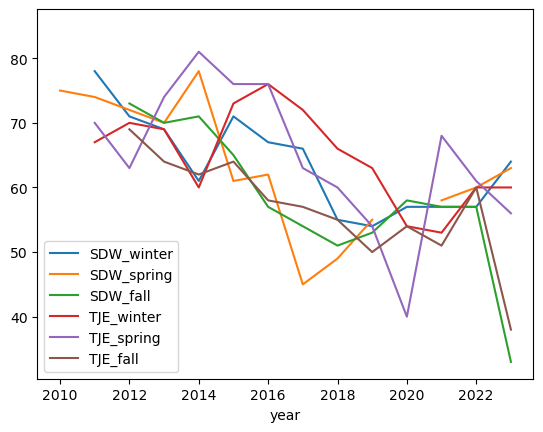

In [12]:
df.set_index('year').loc[:,'SDW_winter':'TJE_fall'].plot()



## Method Chaining
The code used in the check-in

In [ ]:
df.set_index('year').loc[:,'SDW_winter':'TJE_fall'].plot()


is an example of **method chaining**.

Each method in the chain returns a new object (usually a pandas.DataFrame or pandas.Series), allowing the next method to be called directly on the result. This is a powerful technique that **makes code concise and readable**.


Chaining methods can result in lines of code that are too long and hard to read. We can break up chains of methods by using parentheses:

In [ ]:
(df.set_index('year')
  .loc[:,'SDW_winter':'TJE_fall']
  .plot()
)

If you are familiar with R, you may have noticed that the period . in the method chaining plays a similar role to the R pipe operator (%>% or |>).

They are not the same, though: the R pipe passes the result on the left as the first argument of any function, while the period can only call methods that belong to the object on the left.

The syntax of one method per line is similar to what is used in the tidyverse, except that the pipe is used at the end of the line, while the period is used at the beginning of the line.


In [ ]:
year_index_df = df.set_index('year')
subset_df = year_index_df.loc[:,'SDW_winter':'TJE_fall']
subset_df.plot()

# Palmer Penguins
For the next plots we will use the Palmer Penguins dataset [2] developed by Drs. Allison Horst, Alison Hill and Kristen Gorman. This dataset contains size measurements for three penguin species in the Palmer Archipelago, Antarctica, during 2007, 2008, and 2009.

## Data Exploration

In [ ]:
## Read in data
URL = 'https://raw.githubusercontent.com/allisonhorst/palmerpenguins/main/inst/extdata/penguins.csv'
penguins = pd.read_csv(URL)

penguins.head()

In [ ]:
# Check column data types and NA values
penguins.info()

In [ ]:
# Simple statistics about numeric columns
penguins.describe()

In [ ]:
# Count unique values in categorical columns and year
penguins[['species', 'island', 'sex', 'year']].nunique()

In [ ]:
# Get unique values in species column
penguins['species'].unique()

In [ ]:
# Number of values per unique value in species column
penguins['species'].value_counts()

## kind argument in plot()

## Scatter Plots

In [ ]:
penguins.plot(kind='scatter',
              x='flipper_length_mm', 
              y='body_mass_g')

In [ ]:
penguins.plot(kind='scatter',
              x='flipper_length_mm', 
              y='body_mass_g',
              title='Flipper length and body mass for Palmer penguins',
              xlabel='Flipper length (mm)',
              ylabel='Body mass (g)',
              color='#ff3b01',
              alpha=0.4  # Controls transparency
              )

### Bar Plots
We can create bar plots of our data by setting kind='bar' in the plot() method.

For example, let’s say we want to get data about the 10 penguins with the lowest body mass. We can first select this data using the nsmallest() method for series:

In [ ]:
smallest = penguins['body_mass_g'].nsmallest(10)
smallest

In [ ]:
smallest.plot(kind='bar')

In [ ]:
penguins.nsmallest(10, 'body_mass_g')

### Histogram

In [ ]:
# Using plot without subsetting data - a mess again
penguins.plot(kind='hist')

In [ ]:
# Distribution of flipper length measurements
# First select data, then plot
penguins['flipper_length_mm'].plot(kind='hist',
                                title='Penguin flipper lengths',
                                xlabel='Flipper length (mm)',
                                grid=True)

In [ ]:
penguins['bill_length_mm', 'bill_depth_mm'].(plot(kind='box',
                                title='Penguin flipper lengths',
                                xlabel='Flipper length (mm)',
                                grid=True)

In [ ]:
penguins['flipper_length_mm', 'sex == female'].plot(kind='hist',
                                title='Penguin flipper lengths',
                                xlabel='Flipper length (mm)',
                                grid=True)